# Visuals

In [3]:
# %pip install matplotlib
# %pip install seaborn
# %pip install scikit-learn

In [4]:
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import pandas
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
import scipy


## Load data

In [ ]:
path_posteriors = "/buqeval/inferences/trivia_qa_llama-8b-instruct_incl_human_judges.confidences.json"
path_results = "/buqeval/data/trivia_qa_llama-8b-instruct.json"

# path_posteriors = "/buqeval/inferences/ambig_qa_multiple_qas_llama-3b-instruct_100_0.confidences.json"
# path_results = "/buqeval/data/ambig_qa_multiple_qas_llama-3b-instruct.json"

with open(path_results, "r") as f:
    data = json.load(f)

with open(path_posteriors, "r") as f:
    posteriors = json.load(f)

print(f"Loaded {len(data)} items and {len(posteriors)} posterior records")
print("Sample item keys:", list(data[0].keys()))
print("Sample posterior:", posteriors[0])

Loaded 100 items and 700 posterior records
Sample item keys: ['id', 'question', 'answer', 'uncertainty', 'greedy_correctness', 'human_judge1']
Sample posterior: {'item': 'qb_9867', 'system': 'entropy', 'score': -0.0031580586548424737, 'posterior_confidence': 0.7765944600105286}


## Greedy correctness lists

In [8]:
greedy_correctness_lists = defaultdict(list)

for record in data:
    for metric, value in record["greedy_correctness"].items():
        if isinstance(value, dict):
            for threshold, judgment in value.items():
                greedy_correctness_lists[f"{metric}/{threshold}"].append(judgment)
        else:
            greedy_correctness_lists[metric].append(value)

greedy_correctness_lists = dict(greedy_correctness_lists)

print(f"{len(greedy_correctness_lists)} metrics")
for metric, values in sorted(greedy_correctness_lists.items())[:5]:
    print(f"{metric}: {len(values)} values, first 3 = {values[:3]}")

48 metrics
bert_score/0.1: 100 values, first 3 = [True, True, True]
bert_score/0.2: 100 values, first 3 = [True, True, True]
bert_score/0.3: 100 values, first 3 = [True, True, True]
bert_score/0.4: 100 values, first 3 = [True, True, True]
bert_score/0.5: 100 values, first 3 = [True, True, True]


## Posteriors by system

In [9]:
posteriors_dict = defaultdict(list)

for record in posteriors:
    posteriors_dict[record["system"]].append(record["posterior_confidence"])

posteriors_dict = dict(posteriors_dict)

print(f"{len(posteriors_dict)} systems")
for system, values in sorted(posteriors_dict.items()):
    print(f"{system}: {len(values)} values, first 3 = {values[:3]}")

7 systems
entropy: 100 values, first 3 = [0.7765944600105286, 0.799897313117981, 0.6234719753265381]
log_likelihood_seq: 100 values, first 3 = [0.8288847208023071, 0.835273027420044, 0.47075390815734863]
log_likelihood_token: 100 values, first 3 = [0.8680667877197266, 0.19717828929424286, 0.3973284363746643]
p_true: 100 values, first 3 = [0.755585789680481, 0.7946270108222961, 0.8559918999671936]
semantic_confidence: 100 values, first 3 = [0.7976588010787964, 0.7976588010787964, 0.7976588010787964]
semantic_entropy: 100 values, first 3 = [0.9143908023834229, 0.7541235685348511, 0.5515682697296143]
verbalised_confidence: 100 values, first 3 = [0.8432093858718872, 0.8534411191940308, 0.8534411191940308]


In [10]:
human_judge = [x['human_judge1'] for x in data]
human_judge_bool = [True if x == "correct"else False for x in human_judge]

In [11]:
greedy_correctness_lists.keys()

dict_keys(['exact_match', 'token_f1/0.1', 'token_f1/0.2', 'token_f1/0.3', 'token_f1/0.4', 'token_f1/0.5', 'token_f1/0.6', 'token_f1/0.7', 'token_f1/0.8', 'token_f1/0.9', 'bleu/0.1', 'bleu/0.2', 'bleu/0.3', 'bleu/0.4', 'bleu/0.5', 'bleu/0.6', 'bleu/0.7', 'bleu/0.8', 'bleu/0.9', 'rouge_l/0.1', 'rouge_l/0.2', 'rouge_l/0.3', 'rouge_l/0.4', 'rouge_l/0.5', 'rouge_l/0.6', 'rouge_l/0.7', 'rouge_l/0.8', 'rouge_l/0.9', 'embedding_similarity/0.1', 'embedding_similarity/0.2', 'embedding_similarity/0.3', 'embedding_similarity/0.4', 'embedding_similarity/0.5', 'embedding_similarity/0.6', 'embedding_similarity/0.7', 'embedding_similarity/0.8', 'embedding_similarity/0.9', 'bert_score/0.1', 'bert_score/0.2', 'bert_score/0.3', 'bert_score/0.4', 'bert_score/0.5', 'bert_score/0.6', 'bert_score/0.7', 'bert_score/0.8', 'bert_score/0.9', 'llm_as_judge_llama-8b-instruct', 'llm_as_judge_gpt-5.4-mini'])

In [ ]:
df = pandas.DataFrame(greedy_correctness_lists)
df_filt = df

for k in posteriors_dict.keys():
    df_filt[k] = posteriors_dict[k]

df_filt['human_judge'] = human_judge_bool

## Classification labels


In [20]:
import numpy as np

def add_classification_column(
    df,
    ground_truth_col,
    pred_col,
    result_col="classification",
    inplace=False,
):
    """Compare two boolean columns and label each row as TP, TN, FP, or FN.

    ground_truth_col: column with the reference labels
    pred_col: column with the predicted labels
    """
    if ground_truth_col not in df.columns:
        raise KeyError(f"Missing ground-truth column: {ground_truth_col}")
    if pred_col not in df.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    out = df if inplace else df.copy()
    y_true = out[ground_truth_col].astype(bool)
    y_pred = out[pred_col].astype(bool)

    out[result_col] = np.select(
        [y_true & y_pred, ~y_true & ~y_pred, ~y_true & y_pred, y_true & ~y_pred],
        ["TP", "TN", "FP", "FN"],
        default=None,
    )

    return out


In [21]:
judges = ['exact_match', 'token_f1/0.1', 'token_f1/0.2', 'token_f1/0.3',
       'token_f1/0.4', 'token_f1/0.5', 'token_f1/0.6', 'token_f1/0.7',
       'token_f1/0.8', 'token_f1/0.9', 'bleu/0.1', 'bleu/0.2', 'bleu/0.3',
       'bleu/0.4', 'bleu/0.5', 'bleu/0.6', 'bleu/0.7', 'bleu/0.8', 'bleu/0.9',
       'rouge_l/0.1', 'rouge_l/0.2', 'rouge_l/0.3', 'rouge_l/0.4',
       'rouge_l/0.5', 'rouge_l/0.6', 'rouge_l/0.7', 'rouge_l/0.8',
       'rouge_l/0.9', 'embedding_similarity/0.1', 'embedding_similarity/0.2',
       'embedding_similarity/0.3', 'embedding_similarity/0.4',
       'embedding_similarity/0.5', 'embedding_similarity/0.6',
       'embedding_similarity/0.7', 'embedding_similarity/0.8',
       'embedding_similarity/0.9', 'bert_score/0.1', 'bert_score/0.2',
       'bert_score/0.3', 'bert_score/0.4', 'bert_score/0.5', 'bert_score/0.6',
       'bert_score/0.7', 'bert_score/0.8', 'bert_score/0.9',
       'llm_as_judge_llama-8b-instruct', 'llm_as_judge_gpt-5.4-mini']

In [22]:
for judge in judges:
    df_filt = add_classification_column(
        df_filt,
        ground_truth_col="human_judge",
        pred_col=judge,
        result_col=f"{judge}_vs_human",
    )


In [25]:
uqs = ["semantic_confidence",
    "entropy",
    "p_true",
    "semantic_entropy",
    "log_likelihood_token", 
    "log_likelihood_seq",
    "verbalised_confidence",
]

In [26]:
thresholds = np.arange(0.0, 1.0, 0.1)

impacts = {}
scores = []
scores_auroc = []
auroc_diffs = []
f1_scores = []

for uq in uqs:
    impacts[uq] = {}
    for judge in judges:
        impacts[uq][judge] = {}
        judge_error_col = judge + "_vs_human"
        
        try:    
            # auc_score_proxy = roc_auc_score(df_filt[judge], df_filt[uq])

            # Bootstrap
            # if bootstrap:
            auc_diffs = []
            f1_scores_random = []
            for i in range(10):
                sample_indeces = np.arange(len(df_filt))
                random_sample_indeces = np.random.choice(sample_indeces, size=50, replace=False)
                df_filt_random = df_filt.iloc[random_sample_indeces]
                auc_score_proxy_random = roc_auc_score(df_filt_random[judge], df_filt_random[uq])
                auc_score_random = roc_auc_score(df_filt_random["human_judge"], df_filt_random[uq])
                f1_score_random = f1_score(df_filt_random["human_judge"], df_filt_random[judge])
                auc_diff_random = auc_score_proxy_random - auc_score_random
                auc_diffs.append(auc_diff_random)
                f1_scores_random.append(f1_score_random)

            impacts[uq][judge]["auc_score_difference"] = sum(auc_diffs) / len(auc_diffs)
            impacts[uq][judge]["f1_score"] = sum(f1_scores_random) / len(f1_scores_random)
            
            if not np.isnan(impacts[uq][judge]["auc_score_difference"]):
                scores.append(sum(score_list) / len(score_list))
                scores_auroc.append(sum(score_list_auroc) / (num_fp + num_fn))
                f1_scores.append(impacts[uq][judge]["f1_score"])
                auroc_diffs.append(impacts[uq][judge]["auc_score_difference"])
        except:
            print("Not possible to calculate AUROC for", judge)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.1

Not possible to calculate AUROC for token_f1/0.1
Not possible to calculate AUROC for token_f1/0.2
Not possible to calculate AUROC for token_f1/0.3
Not possible to calculate AUROC for token_f1/0.6


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.1

Not possible to calculate AUROC for rouge_l/0.1
Not possible to calculate AUROC for rouge_l/0.2
Not possible to calculate AUROC for rouge_l/0.3
Not possible to calculate AUROC for rouge_l/0.4
Not possible to calculate AUROC for rouge_l/0.5
Not possible to calculate AUROC for rouge_l/0.6


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.1

...

Not possible to calculate AUROC for bleu/0.1
Not possible to calculate AUROC for rouge_l/0.1
Not possible to calculate AUROC for rouge_l/0.2
Not possible to calculate AUROC for rouge_l/0.3
Not possible to calculate AUROC for rouge_l/0.4
Not possible to calculate AUROC for rouge_l/0.5
Not possible to calculate AUROC for embedding_similarity/0.2
Not possible to calculate AUROC for embedding_similarity/0.3


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.1

Not possible to calculate AUROC for embedding_similarity/0.4
Not possible to calculate AUROC for embedding_similarity/0.5
Not possible to calculate AUROC for embedding_similarity/0.6
Not possible to calculate AUROC for embedding_similarity/0.7
Not possible to calculate AUROC for embedding_similarity/0.9


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.1

Not possible to calculate AUROC for bert_score/0.8
Not possible to calculate AUROC for bert_score/0.9
Not possible to calculate AUROC for llm_as_judge_llama-8b-instruct
Not possible to calculate AUROC for llm_as_judge_gpt-5.4-mini


## Plot

In [27]:
judges = [ #'exact_match', # 'bleu/0.6', 
        #  'token_f1/0.4', 'rouge_l/0.5',
        # 'token_f1/0.2', #'rouge_l/0.3',
        # 'bert_score/0.7', 'embedding_similarity/0.3',
        # 'embedding_similarity/0.4', 
        'rouge_l/0.1', 'llm_as_judge_llama-8b-instruct', 'llm_as_judge_gpt-5.4-mini']

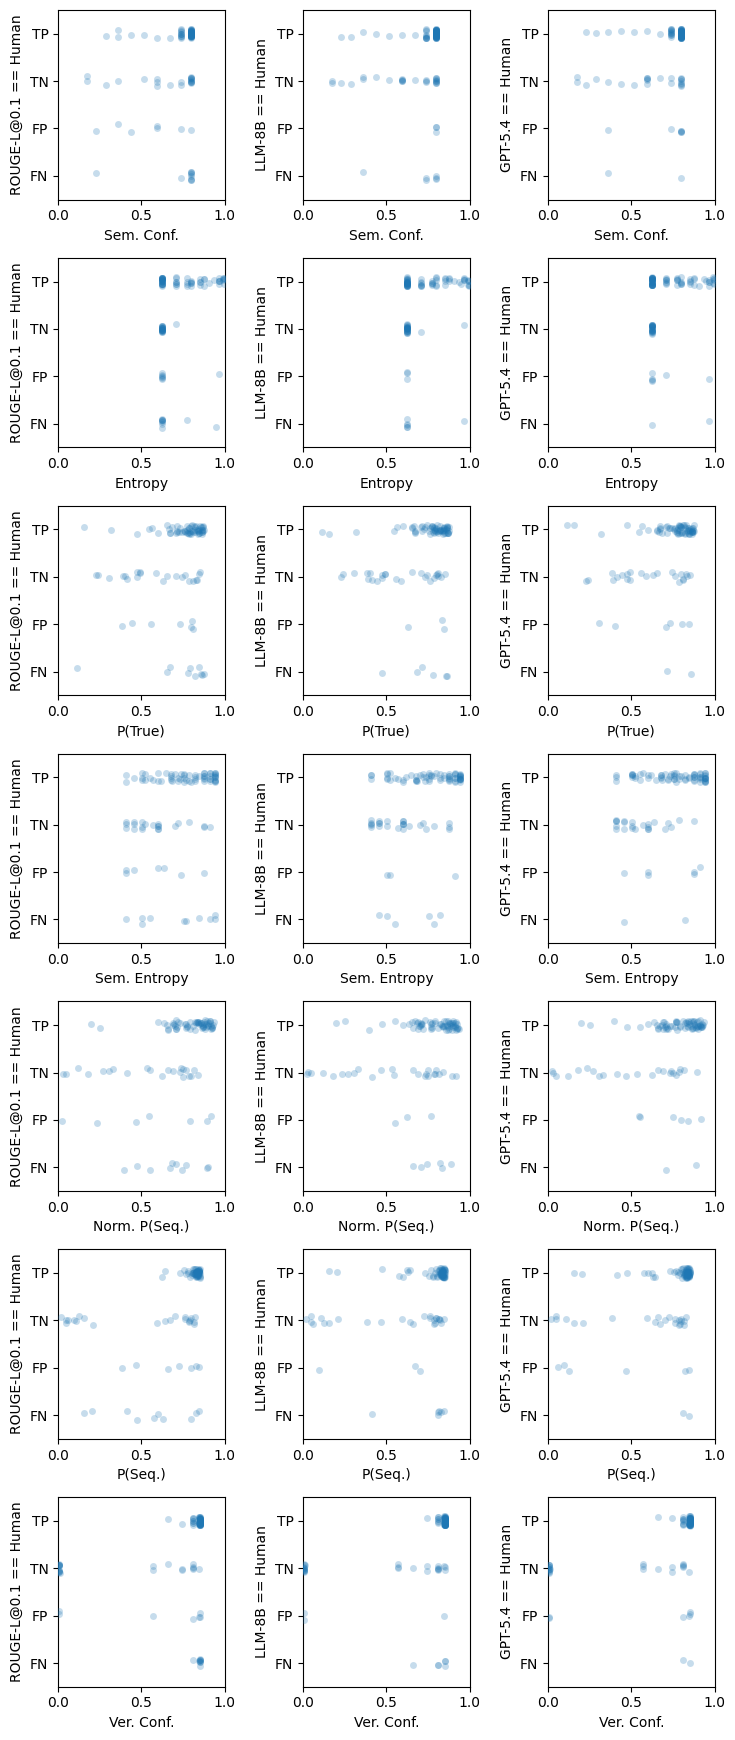

In [ ]:
label_cols = [f"{judge}_vs_human" for judge in judges]
x_cols = ["semantic_confidence",
    "entropy",
    "p_true",
    "semantic_entropy",
    "log_likelihood_token", 
    "log_likelihood_seq",
    "verbalised_confidence",
]
CLASSIFICATION_ORDER = ["TP", "TN", "FP", "FN"]

def draw_plot(ax, df, x_col, label_col, title=None):
    sns.stripplot(
        data=df,
        x=x_col,
        y=label_col,
        order=CLASSIFICATION_ORDER,
        alpha=0.25,
        ax=ax,
    )

    xmin, xmax = 0, 1
    n_cats = len(CLASSIFICATION_ORDER)
    ax.set_xlim(0, 1)

    def map_x_col(x_col):
        dict_map = {
            "entropy": "Entropy",
            "semantic_entropy": "Sem. Entropy",
            "semantic_confidence": "Sem. Conf.",
            "log_likelihood_seq": "P(Seq.)",
            "log_likelihood_token": "Norm. P(Seq.)",
            "p_true": "P(True)",
            "verbalised_confidence": "Ver. Conf.",
        }
        return dict_map[x_col]
    
    ax.set_xlabel(map_x_col(x_col))

    def parse_label_col(label_col):
        label_col = label_col.replace("_vs_human", "")
        
        dict_map = {
            "bleu": "BLEU",
            "exact_match": "EM",
            "token_f1": "F1",
            "rouge_l": "ROUGE-L",
            "embedding_similarity": "Emb. Sim.",
            "llm_as_judge_llama-8b-instruct": "LLM-8B",
            "llm_as_judge_gpt-5.4-mini": "GPT-5.4",
        }

        if not "llm_as_judge" in label_col:
            threshold = label_col.split("/")[-1]
            metric = label_col.split("/")[0]
            return f"{dict_map[metric]}@{threshold} == Human"
        else:
            metric = label_col
            return f"{dict_map[metric]} == Human"
      
    ax.set_ylabel(parse_label_col(label_col))

    if title is not None:
        ax.set_title(title)
    
n_label_cols = len(label_cols)
n_cols = n_label_cols
SUBPLOT_WIDTH = 2.5   # inches per subplot column; increase to widen the figure
SUBPLOT_HEIGHT = 2.5  # inches per subplot row
fig, axes = plt.subplots(
    len(x_cols),
    n_cols,
    figsize=(SUBPLOT_WIDTH * n_cols, SUBPLOT_HEIGHT * len(x_cols)),
    sharex="row",
)
if len(x_cols) == 1:
    axes = axes.reshape(1, -1)


for i, x_col in enumerate(x_cols):
    for j, label_col in enumerate(label_cols):
        draw_plot(
            axes[i, j],
            df_filt,
            x_col,
            label_col,
        )

fig.tight_layout()
plt.savefig("/buqeval/visuals/visuals-errors-vs-confidence.pdf")


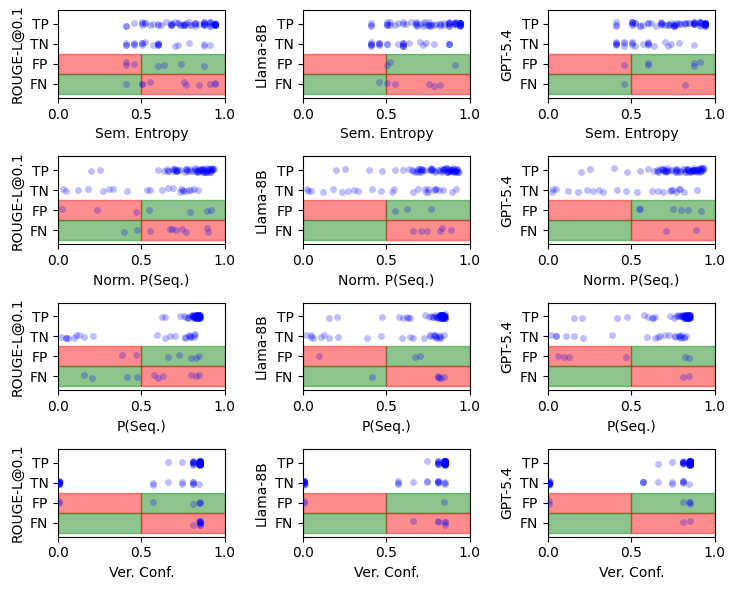

In [29]:
label_cols = [f"{judge}_vs_human" for judge in judges]
x_cols = [#"semantic_confidence",
    # "entropy",
    # "p_true",
    "semantic_entropy",
    "log_likelihood_token", 
    "log_likelihood_seq",
    "verbalised_confidence",
]
CLASSIFICATION_ORDER = ["TP", "TN", "FP", "FN"]

BOX_COLORS = [
    "white", "white",
    "white", "white",
    "red", "green",
    "green", "red",
]


def draw_plot(ax, df, x_col, label_col, box_colors, title=None):
    sns.stripplot(
        data=df,
        x=x_col,
        y=label_col,
        order=CLASSIFICATION_ORDER,
        alpha=0.25,
        ax=ax,
        color="blue"
    )
    
    x_split = 0.5
    xmin, xmax = 0, 1
    n_cats = len(CLASSIFICATION_ORDER)
    n_box_cols = 2
    assert len(box_colors) == n_cats * n_box_cols
    ax.set_xlim(0, 1)

    for i in range(n_cats):
        y0, y1 = i - 0.5, i + 0.5
        for j, (x0, x1) in enumerate([(xmin, x_split), (x_split, xmax)]):
            box_idx = i * n_box_cols + j
            ax.fill_betweenx(
                [y0, y1],
                x0,
                x1,
                color=box_colors[box_idx],
                alpha=0.45,
                zorder=0,
            )

    def map_x_col(x_col):
        dict_map = {
            "entropy": "Entropy",
            "semantic_entropy": "Sem. Entropy",
            "semantic_confidence": "Sem. Conf.",
            "log_likelihood_seq": "P(Seq.)",
            "log_likelihood_token": "Norm. P(Seq.)",
            "p_true": "P(True)",
            "verbalised_confidence": "Ver. Conf.",
        }
        return dict_map[x_col]
    
    ax.set_xlabel(map_x_col(x_col))

    def parse_label_col(label_col):
        label_col = label_col.replace("_vs_human", "")
        
        dict_map = {
            "bleu": "BLEU",
            "exact_match": "EM",
            "token_f1": "F1",
            "rouge_l": "ROUGE-L",
            "embedding_similarity": "Emb. Sim.",
            "llm_as_judge_llama-8b-instruct": "Llama-8B",
            "llm_as_judge_gpt-5.4-mini": "GPT-5.4",
        }

        if not "llm_as_judge" in label_col:
            threshold = label_col.split("/")[-1]
            metric = label_col.split("/")[0]
            return f"{dict_map[metric]}@{threshold}"
        else:
            metric = label_col
            return f"{dict_map[metric]}"
      
    ax.set_ylabel(parse_label_col(label_col))

    if title is not None:
        ax.set_title(title)
    
n_label_cols = len(label_cols)
n_cols = n_label_cols
SUBPLOT_WIDTH = 2.5   # inches per subplot column; increase to widen the figure
SUBPLOT_HEIGHT = 1.5  # inches per subplot row
fig, axes = plt.subplots(
    len(x_cols),
    n_cols,
    figsize=(SUBPLOT_WIDTH * n_cols, SUBPLOT_HEIGHT * len(x_cols)),
    sharex="row",
)
if len(x_cols) == 1:
    axes = axes.reshape(1, -1)


for i, x_col in enumerate(x_cols):
    for j, label_col in enumerate(label_cols):
        draw_plot(
            axes[i, j],
            df_filt,
            x_col,
            label_col,
            BOX_COLORS
        )
        # draw_plot(
        #     axes[i, 2 * j + 1],
        #     df_filt,
        #     x_col,
        #     label_col,
        # )

fig.tight_layout()

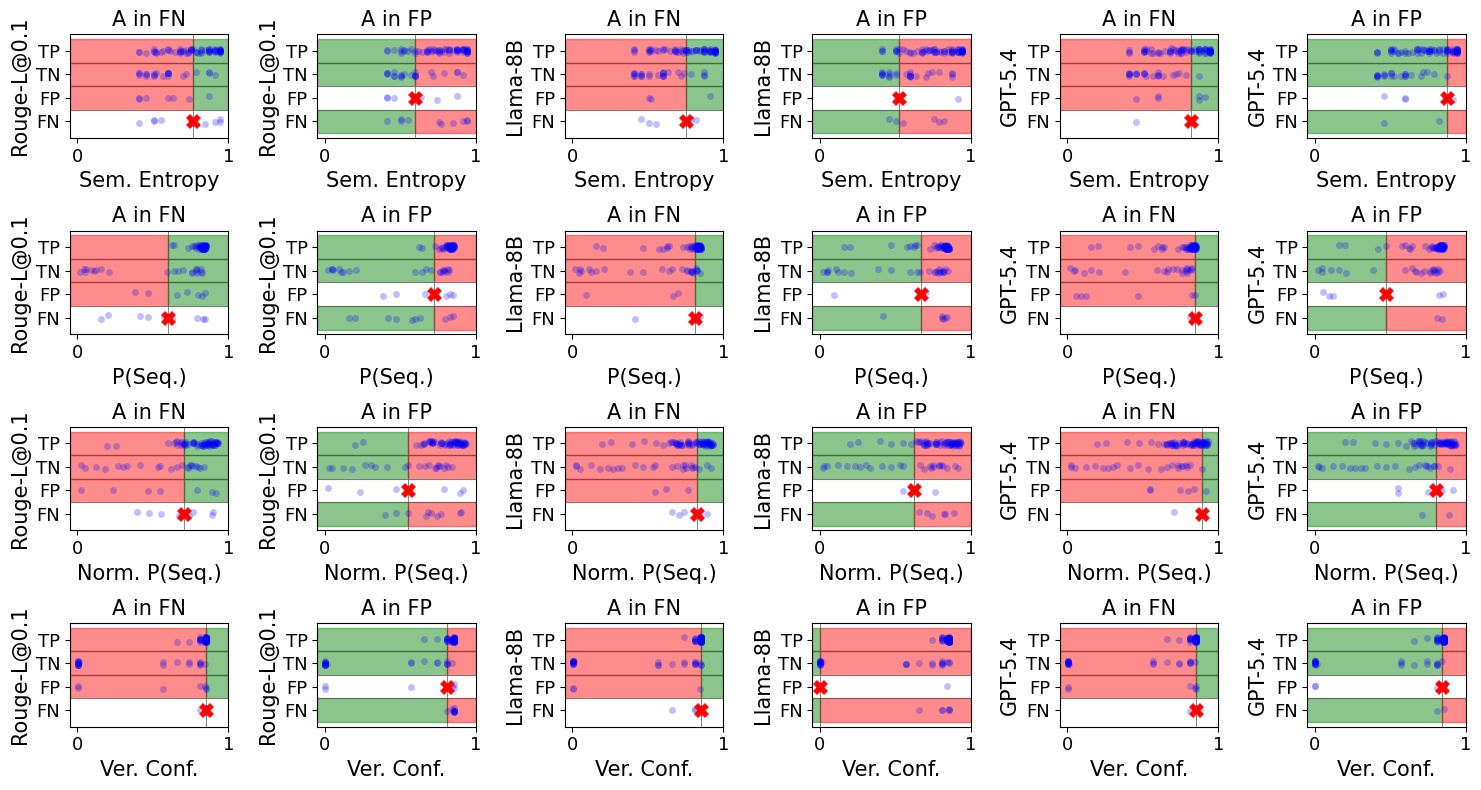

In [30]:
label_cols = [f"{judge}_vs_human" for judge in judges]
x_cols = [
    # "entropy",
    "semantic_entropy",
    # "semantic_confidence",
    "log_likelihood_seq",
    "log_likelihood_token",
    # "p_true",
    "verbalised_confidence",
]
CLASSIFICATION_ORDER = ["TP", "TN", "FP", "FN"]

BOX_COLORS_FN = [
    "red", "green",
    "red", "green",
    "red", "green",
    "white", "white",
]
BOX_COLORS_FP = [
    "green", "red",
    "green", "red",
    "white", "white",
    "green", "red",
]


def draw_highlight_plot(ax, df, x_col, label_col, highlight, box_colors, title):
    sns.stripplot(
        data=df,
        x=x_col,
        y=label_col,
        order=CLASSIFICATION_ORDER,
        alpha=0.25,
        ax=ax,
        color="blue"
    )
    
    if highlight is not None:
        x_split = highlight[x_col]

    xmin, xmax = -0.05, 1
    n_cats = len(CLASSIFICATION_ORDER)
    n_box_cols = 2
    assert len(box_colors) == n_cats * n_box_cols

    if highlight is not None:
        for i in range(n_cats):
            y0, y1 = i - 0.5, i + 0.5
            for j, (x0, x1) in enumerate([(xmin, x_split), (x_split, xmax)]):
                box_idx = i * n_box_cols + j
                ax.fill_betweenx(
                    [y0, y1],
                    x0,
                    x1,
                    color=box_colors[box_idx],
                    alpha=0.45,
                    zorder=0,
                )

    ax.set_xlim(-0.05, 1)
    if highlight is not None:
        ax.axvline(x_split, color="#555555", linewidth=0.5, zorder=1)
        for i in range(1, n_cats):
            ax.axhline(i - 0.5, color="#555555", linewidth=0.5, zorder=1)

        ax.scatter(
            [highlight[x_col]],
            [highlight[label_col]],
            color="red",
            marker="X",
            s=100,
            linewidths=0.5,
            zorder=10,
        )
    ax.set_title(title, fontsize=15)

    def map_x_col(x_col):
        dict_map = {
            "entropy": "Entropy",
            "semantic_entropy": "Sem. Entropy",
            "semantic_confidence": "Sem. Conf.",
            "log_likelihood_seq": "P(Seq.)",
            "log_likelihood_token": "Norm. P(Seq.)",
            "p_true": "P(True)",
            "verbalised_confidence": "Ver. Conf.",
        }
        return dict_map[x_col]
    ax.set_xlabel(map_x_col(x_col), fontsize=15)

    def parse_label_col(label_col):
        label_col = label_col.replace("_vs_human", "")
        
        dict_map = {
            "bleu": "BLEU",
            "exact_match": "EM",
            "token_f1": "F1",
            "rouge_l": "Rouge-L",
            "embedding_similarity": "Emb. Sim.",
            "llm_as_judge_llama-8b-instruct": "Llama-8B",
            "llm_as_judge_gpt-5.4-mini": "GPT-5.4",
        }

        if not "llm_as_judge" in label_col:
            threshold = label_col.split("/")[-1]
            metric = label_col.split("/")[0]
            return f"{dict_map[metric]}@{threshold}"
        else:
            metric = label_col
            return f"{dict_map[metric]}"
        
        
    ax.set_ylabel(parse_label_col(label_col), fontsize=15)
    ax.tick_params(axis='both', labelsize=13)


def pick_highlight(df, label_col, x_col, error_label):
    subset = df[df[label_col] == error_label]
    if len(subset) == 0:
        return None
    subset_sorted = subset.sort_values(x_col)
    return subset_sorted.iloc[len(subset_sorted) // 2]


n_label_cols = len(label_cols)
n_cols = 2 * n_label_cols
SUBPLOT_WIDTH = 2.5   # inches per subplot column; increase to widen the figure
SUBPLOT_HEIGHT = 2  # inches per subplot row
fig, axes = plt.subplots(
    len(x_cols),
    n_cols,
    figsize=(SUBPLOT_WIDTH * n_cols, SUBPLOT_HEIGHT * len(x_cols)),
    sharex="row",
)
if len(x_cols) == 1:
    axes = axes.reshape(1, -1)


for i, x_col in enumerate(x_cols):
    for j, label_col in enumerate(label_cols):
        highlight_fn = pick_highlight(df_filt, label_col, x_col, "FN")
        highlight_fp = pick_highlight(df_filt, label_col, x_col, "FP")
        draw_highlight_plot(
            axes[i, 2 * j],
            df_filt,
            x_col,
            label_col,
            highlight_fn,
            BOX_COLORS_FN,
            f"A in FN",
        )
        draw_highlight_plot(
            axes[i, 2 * j + 1],
            df_filt,
            x_col,
            label_col,
            highlight_fp,
            BOX_COLORS_FP,
            f"A in FP",
        )

fig.tight_layout()